# Описание задачи "Кластеризация физической активности"

В современном мире существуют множество различных устройств (фитнес-браслетов, камер, датчиков и т.д.), которые собирают данные об активности пользователя. Эти сведения могут быть использованы, например, для отслеживания состояния здоровья человека и определение находится ли он сейчас в безопасности, что он делает и так далее.

Данные, собранные с носимых устройств, которые отслеживают физическую активность пользователей, используются во множестве коммерческих приложений, включая здравоохранение, фитнес-тренировки, навигационную систему и так далее.

В данной задаче вам предлагается, используя информацию, собранную с помощью трех Инерциальных измерительных модуля (IMU) и пульсометра.

[Ссылка на Kaggle](https://www.kaggle.com/competitions/clustering-physical-activity-data/)

**Датасет содержит по 54 столбца на строку, столбцы содержат следующие данные:**
- 1 временная метка (с)
- 2 частота сердечных сокращений (уд/мин)
- 3-19 данные с датчиков на руке
- 20-36 данные с датчиков на груди
- 37-53 данные с датчиков на лодыжке

**Сенсорные данные IMU содержат следующие столбцы:**
- 1 температура (°C)
- 2-4 Данные 3D-ускорения (мс-2), масштаб: ±16g, разрешение: 13 бит
- 5-7 Данные 3D-ускорения (мс-2), масштаб: ±6g, разрешение: 13 бит*
- 8-10 данных 3D-гироскопа (рад/с)
- 11-13 Данные 3D-магнитометра (мкТл)

**Что нужно сделать**

1. Принять участие в соревновании на [Kaggle](https://www.kaggle.com/competitions/clustering-physical-activity-data/).
2. Разработать и оформить решение в ноутбуке:
   * Исследование и анализ датасета.
   * Предобработка данных.
   * Feature Engineering (если необходимо).
   * Подбор признаков, их анализ и оценка важности.
   * Обучение нескольких моделей, их сравнение.
   * Подбор гиперпараметров.
   * Выбор лучшей модели и объяснение выбора.
   * Предсказание на тестовых данных. (Результат должен быть воспроизводимым!)
3. Закрепить в ноутбуке скриншот с лидерборда Kaggle.
4. Прикрепить ноутбук (.ipynb) с решением на платформу.
    * Требования к ноутбуку:
       * Комментарии и пояснения к коду.
       * Выводы к каждому этапу (анализ данных, предобработка, обучение).
       * Код должен быть чистым и читаемым.

|**Критерии оценивания**||
|:---|:---|
|Анализ данных и их предобработка	|0-3 балла|
|Feature Engineering и отбор признаков	|0-2 балла|
|Выбор и обучение нескольких моделей	|0-3 балла|
|Подбор гиперпараметров и объяснение выбора лучшей модели	|0-2 балла|
|Результат на Kaggle	|0-1 балл|
|Качество оформления ноутбука (чистый код, комментарии, выводы)	|0-1 балл|
|**Максимальное количество баллов**	|**12 баллов**|


# Загрузка данных и установка констант

## Импортирование библиотек

In [108]:
# base
import pandas
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
import warnings

from pandas.plotting import scatter_matrix

# for Kagle datasets loading
import opendatasets as od

# from scikit-learn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# from Yellowbrick # machine learning visualization (scikit-learn + matplotlib)
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import silhouette_visualizer

# Missingno # missing data visualization
import missingno as msno

# service
from IPython.display import Image # imageshow
import joblib # save to pickle


In [109]:
# warnings.filterwarnings("ignore")

## Загрузка данных

In [110]:
# Загрузим датасет на прямую с kaggle
# Для автоматическй загрузки надо положить файл kaggle.json в папку с ноутбуком
# kaggle.json скачивается в настройках Kaggle в разделе Legacy API Credentials
dataset_url = 'https://www.kaggle.com/competitions/clustering-physical-activity-data/data'

od.download(dataset_url)

Skipping, found downloaded files in "./clustering-physical-activity-data" (use force=True to force download)


In [111]:
# Здесь у нас нет ответов, поэтому только матрица X
X_original = pd.read_csv("./clustering-physical-activity-data/Physical_Activity_Monitoring_unlabeled.csv")


In [112]:
X = X_original.copy()

In [113]:
X.columns

Index(['timestamp', 'handTemperature', 'handAcc16_1', 'handAcc16_2',
       'handAcc16_3', 'handAcc6_1', 'handAcc6_2', 'handAcc6_3', 'handGyro1',
       'handGyro2', 'handGyro3', 'handMagne1', 'handMagne2', 'handMagne3',
       'handOrientation1', 'handOrientation2', 'handOrientation3',
       'handOrientation4', 'chestTemperature', 'chestAcc16_1', 'chestAcc16_2',
       'chestAcc16_3', 'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3',
       'chestGyro1', 'chestGyro2', 'chestGyro3', 'chestMagne1', 'chestMagne2',
       'chestMagne3', 'chestOrientation1', 'chestOrientation2',
       'chestOrientation3', 'chestOrientation4', 'ankleTemperature',
       'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'ankleAcc6_1',
       'ankleAcc6_2', 'ankleAcc6_3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3',
       'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'ankleOrientation1',
       'ankleOrientation2', 'ankleOrientation3', 'ankleOrientation4',
       'subject_id'],
      dtype='str')

## Исследование данных

Прежде чем переходить к непосредственному построению модели, в первую очередь необходимо исследовать имеющихся у вас набор данных:
1. Какую задачу вы решаете (классификация, регрессия) и какая переменная является целевой?
2. Сколько переменных в данных и какого они типа?
3. Имеются ли в данных пропуски?

In [114]:
X.shape

(534601, 53)

In [115]:
missing_values = X.isnull().sum()  # Количество пропусков
total_rows = len(X)  # Общее число строк

# Фильтруем только столбцы с пропусками
missing_data = missing_values[missing_values > 0].to_frame(name="Missing Count")
missing_data["Missing Fraction"] = (missing_data["Missing Count"] / total_rows)

missing_data

,Missing Count,Missing Fraction
handTemperature,4041,0.007559
handAcc16_1,4041,0.007559
handAcc16_2,4041,0.007559
handAcc16_3,4041,0.007559
handAcc6_1,4041,0.007559
handAcc6_2,4041,0.007559
handAcc6_3,4041,0.007559
handGyro1,4041,0.007559
handGyro2,4041,0.007559
handGyro3,4041,0.007559


In [116]:
missing_data.shape

(51, 2)

## Корреляционная матрица

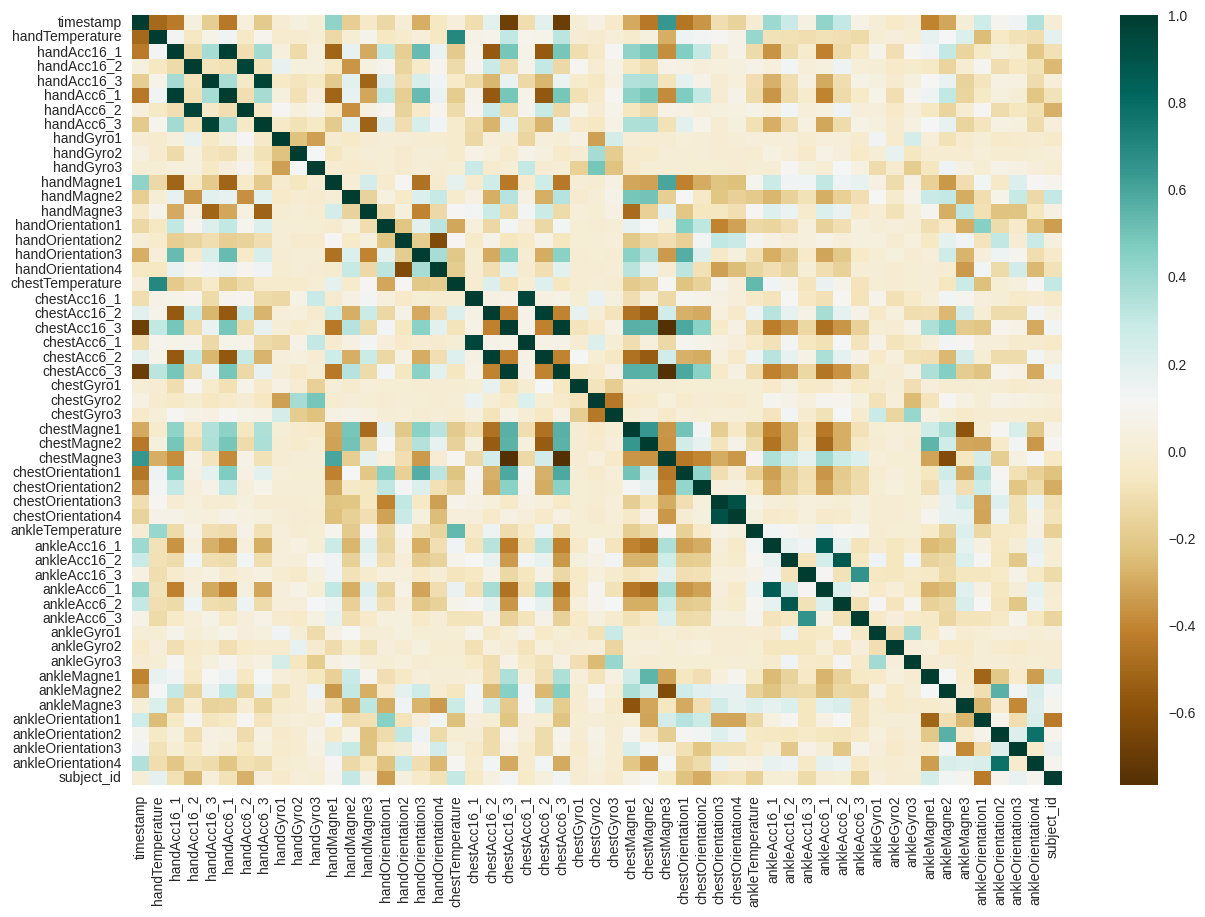

In [117]:

df_corr = X.corr()

f, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(df_corr, mask=np.zeros_like(df_corr, dtype=np.bool), cmap = "BrBG",ax=ax)
plt.show()

## График пропусков

In [118]:
df = X

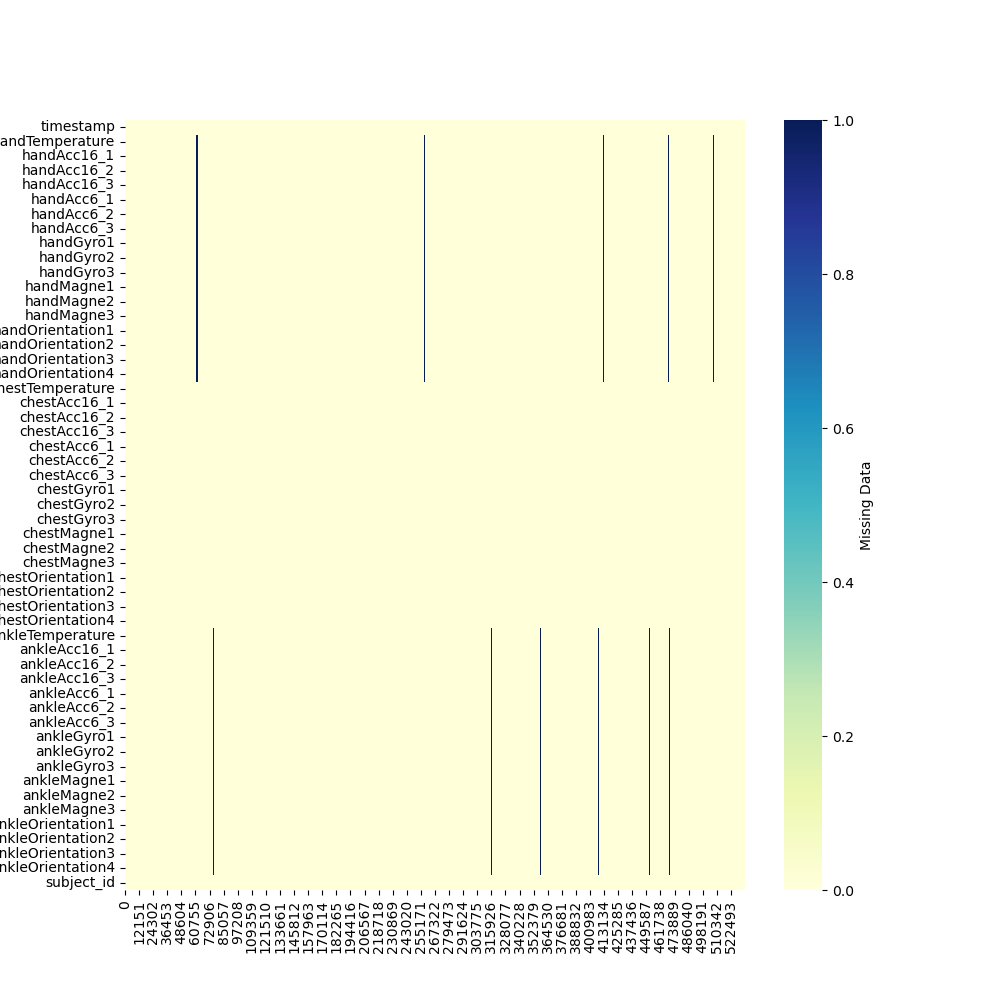

In [119]:

Image(filename="./clustering-physical-activity-data/visualizing_missing_data_with_heatmap_Seaborn_Python.png") 


**Библиотека визуализации пропусков:**

`pip install missingno`

<Axes: >

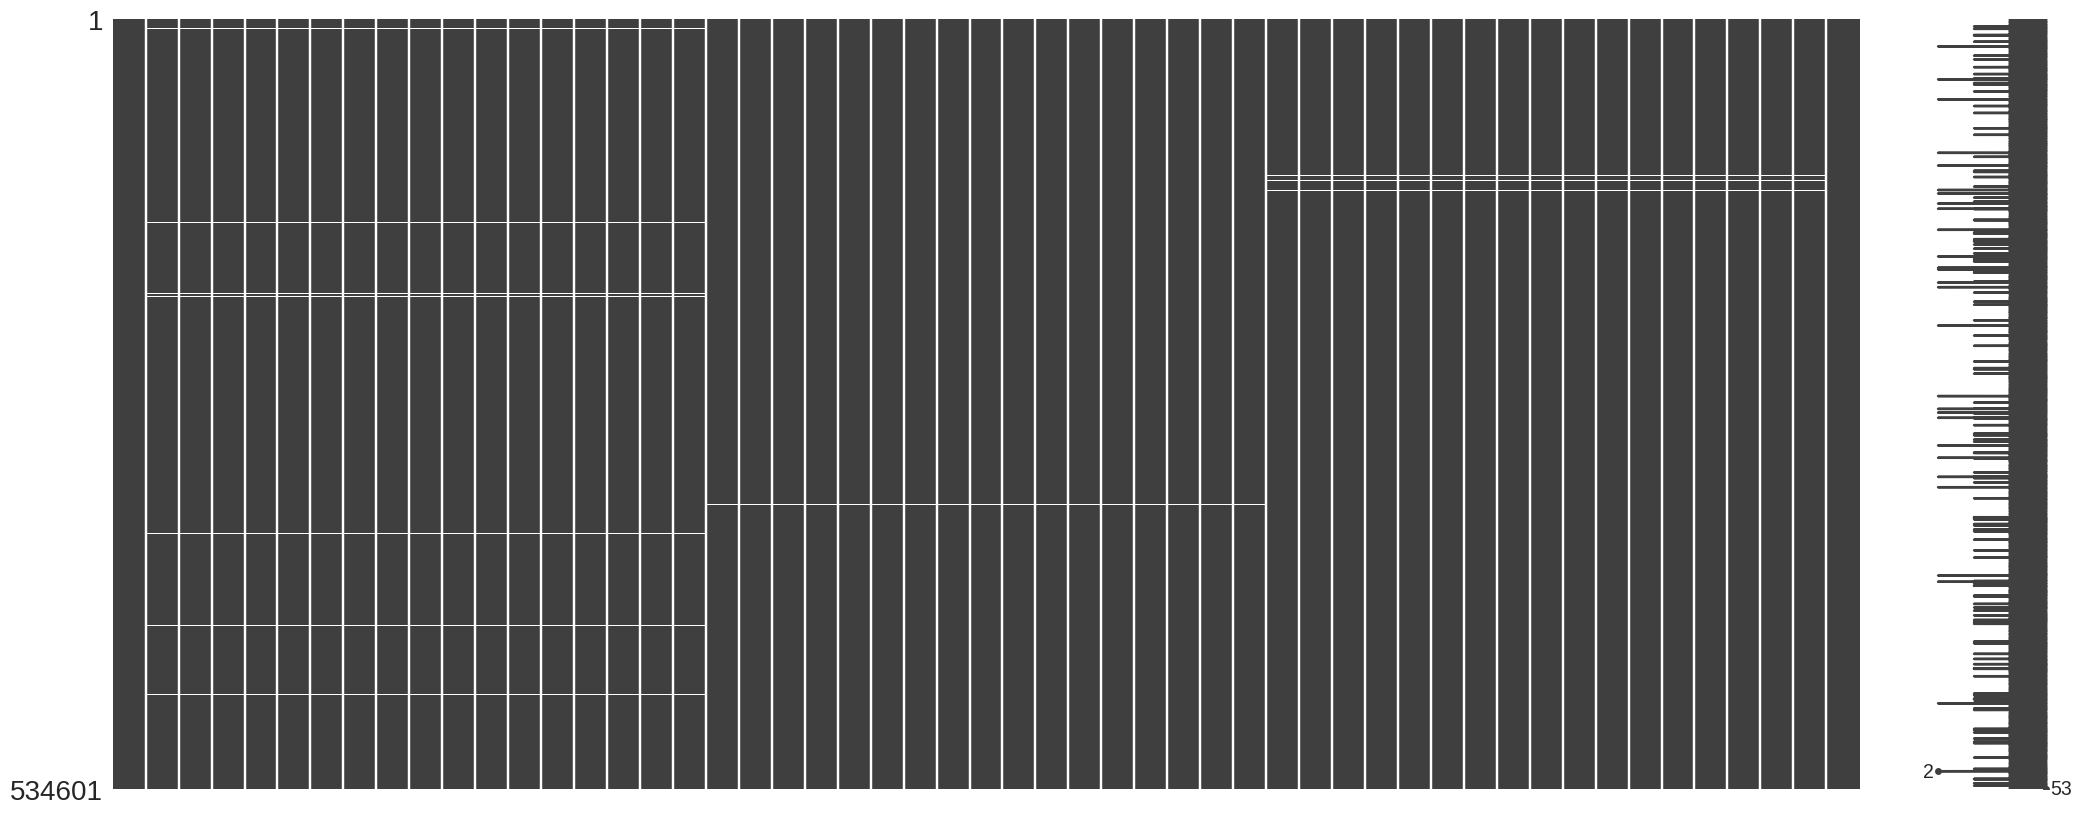

In [120]:
msno.matrix(df)

**Ка видим в данных у нас имеются множество пропущенных значений.**

Так как датасет собран из реальных данных, то в жизни случается всякое.

Пустые значения в данном случае могут быть обусловлены следующими факторами:
* Потеря данных из-за использования беспроводных датчиков.
* Проблемы с настройкой оборудования, вызывающие, например. потерю соединения с датчиками или системный сбой.

Существуют две основные стратегии при работе с пропусками:
1. Удаление пропущенных значений
2. Заполнение пропусков

**Удаление.**

При удалении пропусков можно:
1. Удалять как целиком какой-то признак (например, если больше 70% для этого признака это пропуски, тогда мы можем целиком удалить данный столбец):
`df.drop(columns='name'])`

2. Удалить можно объекты у которых имеются пропущенные значения, т.е. в данном случае мы удаляем строки. *Но будьте внимательны так как удалять из тестового набора данных не всегда возможно, иначе размерность ответов не совпадет.*
`df.dropna()`

**Заполнение.**

При заполнении пропусков также существует множество различных стратегий:
- заполнение пропусков с помощью **среднего/медианы/максимума/минимум** по данному признаку.
- при категориальных признаках пропуски можно заполнить пропущенные значения с помощью наиболее часто встречающейся категории по данному признаку (**модой**).
- используя **интерполяцию** - нахождение неизвестных промежуточных значений некоторой функции, по имеющемуся дискретному набору её известных значений, определенным способом.
- используя различные **другие алгоритмы машинного обучения** для заполнения пропусков (представьте, что все строки с пропусками - это тестовый набор данных, для которого вам нужно вернуть ответ).

Табличка в помощь:
https://help.loginom.ru/userguide/processors/preprocessing/imputation.html

In [121]:
X.columns

Index(['timestamp', 'handTemperature', 'handAcc16_1', 'handAcc16_2',
       'handAcc16_3', 'handAcc6_1', 'handAcc6_2', 'handAcc6_3', 'handGyro1',
       'handGyro2', 'handGyro3', 'handMagne1', 'handMagne2', 'handMagne3',
       'handOrientation1', 'handOrientation2', 'handOrientation3',
       'handOrientation4', 'chestTemperature', 'chestAcc16_1', 'chestAcc16_2',
       'chestAcc16_3', 'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3',
       'chestGyro1', 'chestGyro2', 'chestGyro3', 'chestMagne1', 'chestMagne2',
       'chestMagne3', 'chestOrientation1', 'chestOrientation2',
       'chestOrientation3', 'chestOrientation4', 'ankleTemperature',
       'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'ankleAcc6_1',
       'ankleAcc6_2', 'ankleAcc6_3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3',
       'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'ankleOrientation1',
       'ankleOrientation2', 'ankleOrientation3', 'ankleOrientation4',
       'subject_id'],
      dtype='str')

In [122]:
missing_data.T.columns

Index(['handTemperature', 'handAcc16_1', 'handAcc16_2', 'handAcc16_3',
       'handAcc6_1', 'handAcc6_2', 'handAcc6_3', 'handGyro1', 'handGyro2',
       'handGyro3', 'handMagne1', 'handMagne2', 'handMagne3',
       'handOrientation1', 'handOrientation2', 'handOrientation3',
       'handOrientation4', 'chestTemperature', 'chestAcc16_1', 'chestAcc16_2',
       'chestAcc16_3', 'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3',
       'chestGyro1', 'chestGyro2', 'chestGyro3', 'chestMagne1', 'chestMagne2',
       'chestMagne3', 'chestOrientation1', 'chestOrientation2',
       'chestOrientation3', 'chestOrientation4', 'ankleTemperature',
       'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'ankleAcc6_1',
       'ankleAcc6_2', 'ankleAcc6_3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3',
       'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'ankleOrientation1',
       'ankleOrientation2', 'ankleOrientation3', 'ankleOrientation4'],
      dtype='str')

In [123]:
# Заполним пропуски медианой
for i in missing_data.T.columns:
    X[i] = X[i].fillna(X[i].median())

X.isna().sum()

timestamp            0
handTemperature      0
handAcc16_1          0
handAcc16_2          0
handAcc16_3          0
handAcc6_1           0
handAcc6_2           0
handAcc6_3           0
handGyro1            0
handGyro2            0
handGyro3            0
handMagne1           0
handMagne2           0
handMagne3           0
handOrientation1     0
handOrientation2     0
handOrientation3     0
handOrientation4     0
chestTemperature     0
chestAcc16_1         0
chestAcc16_2         0
chestAcc16_3         0
chestAcc6_1          0
chestAcc6_2          0
chestAcc6_3          0
chestGyro1           0
chestGyro2           0
chestGyro3           0
chestMagne1          0
chestMagne2          0
chestMagne3          0
chestOrientation1    0
chestOrientation2    0
chestOrientation3    0
chestOrientation4    0
ankleTemperature     0
ankleAcc16_1         0
ankleAcc16_2         0
ankleAcc16_3         0
ankleAcc6_1          0
ankleAcc6_2          0
ankleAcc6_3          0
ankleGyro1           0
ankleGyro2 

In [124]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    534601 non-null  float64
 2   handAcc16_1        534601 non-null  float64
 3   handAcc16_2        534601 non-null  float64
 4   handAcc16_3        534601 non-null  float64
 5   handAcc6_1         534601 non-null  float64
 6   handAcc6_2         534601 non-null  float64
 7   handAcc6_3         534601 non-null  float64
 8   handGyro1          534601 non-null  float64
 9   handGyro2          534601 non-null  float64
 10  handGyro3          534601 non-null  float64
 11  handMagne1         534601 non-null  float64
 12  handMagne2         534601 non-null  float64
 13  handMagne3         534601 non-null  float64
 14  handOrientation1   534601 non-null  float64
 15  handOrientation2   534601 non-null  float64
 16  handOrientati

In [125]:
X.isna().sum().sum()

np.int64(0)

In [126]:
df = X

## Кластеризация

Для кластеризации в данном примере мы будем использовать **KMeans**.

In [127]:
%%time

n_clusters = 10

clusterer = KMeans(n_clusters=n_clusters)

cluster_labels = clusterer.fit_predict(X)

# inertia
inertia = clusterer.inertia_

CPU times: user 3.51 s, sys: 231 ms, total: 3.74 s
Wall time: 802 ms


In [128]:
print("For n_clusters =", n_clusters,
      ", the inertia is :", inertia)

For n_clusters = 10 , the inertia is : 4344928526.842879


In [129]:
%%time

# Рассчитает силуэт для случайных 10 000 объектов
silhouette_avg_sample = silhouette_score(df, cluster_labels, sample_size=25000)


CPU times: user 19.1 s, sys: 7.35 s, total: 26.4 s
Wall time: 5.41 s


In [130]:
silhouette_avg_sample

0.4742888869823284

In [131]:
silhouette_avg = silhouette_avg_sample

**Как оценить качество получившегося кластерного разбиения?**

**Коэффициент Силуэтта**

К-т Силуэтта (англ *Silhouette*) - это метрика, которая не предполагает знания истинных меток объектов, и позволяет оценить качество кластеризации, используя только саму (неразмеченную) выборку и результат кластеризации.

Интуитивное описание метрики:
* точки внутри кластера должны лежать очень близко друг к другу, то есть кластер должен быть *плотным*
* сами кластера должны лежать как можно дальше друг от друга

Метрика силуэта позволяет учитывать оба этих факта в одной формуле.

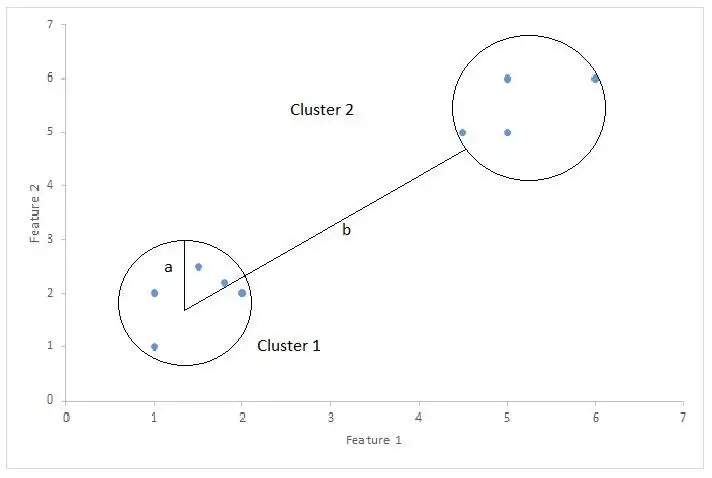

Чтобы вычислить его для каждого объекта нужно вычислить для каждого объекта выборки две величины, $a$ (среднее расстояние от данного объекта до объектов из того же кластера) и $b$ (среднее расстояние от данного объекта до объектов из ближайшего кластера (отличного от того, в котором лежит сам объект)).

Силуэтом объекта назовём нормализованную разность между этими величинами

$$
s = \frac{b-a}{\max(a,b)}
$$

Силуэтом выборки называется средняя величина силуэта объектов данной выборки. Таким образом, силуэт показывает, насколько среднее расстояние до объектов своего кластера отличается от среднего расстояния до объектов других кластеров. Эта величина меняется в интервале от $-1$ до $1$:

* -1 значит что кластера плохие, размытые
* 0 значит что кластера накладываются друг на друга
* 1 значит что кластера плотные и хорошо отделены друг от друга

Таким образом, чем ближе значение к-та Силуэтта в единице, тем лучше. Все, что больше $0.5$ хорошие значения, всё что меньше - надо улучшать.

Формулу реализовывать не надо, она уже есть в *sklearn*. Для примера загрузим наш датасет с кластеризацией:

**Инерция**

Инерция показывает, насколько когерентны различные кластеры.

Вычисляется по следующей формуле:

$inertia = \sum_{i=1}^N (x_i - C_k)$

* N — количество выборок в наборе данных
* C — центр кластера.

Таким образом, Inertia просто вычисляет квадрат расстояния от каждой выборки в кластере до его центра кластера и суммирует их. Этот процесс выполняется для каждого кластера и всех выборок в этом наборе данных. Чем меньше значение Inertia, тем более когерентны различные кластеры. Когда добавляется столько кластеров, сколько имеется выборок в наборе данных, значение инерции будет равно нулю.

In [132]:
print("For n_clusters =", n_clusters,
      ", the silhouette is :", silhouette_avg)

For n_clusters = 10 , the silhouette is : 0.4742888869823284


In [133]:
import numpy as np

len(np.unique(cluster_labels))

10

## Оптимальное количество кластеров

**В данном примере, мы выбрали рандомное число кластеров. И тут встает вопрос как подобрать оптимальное и подходящее количество кластеров для датасета?**

https://habr.com/ru/company/jetinfosystems/blog/467745/

Собственно используя коэффицент Силуэта и инерцию, можно додобрать оптимальное количество кластеров, а также гиперпараметры для KMeans.

**Существует несколько различных стратегий подбора оптимального количества кластеров:**
1. Метод локтя
2. Gap-Statistics (https://towardsdatascience.com/k-means-clustering-and-the-gap-statistics-4c5d414acd29)
3. Метод силуэтов https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

### Метод локтя

**Метод локтя** – один из самых известных методов, с помощью которого вы можете выбрать правильное значение k и повысить производительность Модели (Model). Этот эмпирический метод вычисляет сумму квадратов расстояний между точками и вычисляет Среднее значение (Mean).

**Метод "локтя" (elbow method)** рассматривает характер изменения разброса  $W_{total}$  с увеличением числа групп  $k$ . Объединив все {n} наблюдений в одну группу, мы имеем наибольшую внутрикластерную дисперсию, которая будет снижаться до 0 при  $k→n$ . На каком-то этапе можно усмотреть, что снижение этой дисперсии замедляется - на графике это происходит в точке, называемой "локтем". Построить такой график можно в результате прямого перебора.

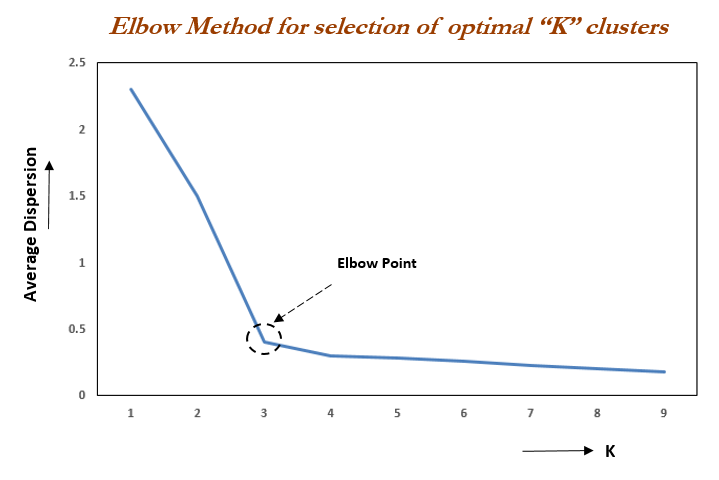

In [134]:
%%time
from sklearn.cluster import KMeans

inertia_df = pd.DataFrame(data=[], index=range(3, 12), columns=['inertia'])

for n_clusters in range(3, 22):
    clusterer = KMeans(n_clusters=n_clusters,  random_state=42)
    cluster_labels = clusterer.fit_predict(X)

    # inertia
    inertia_df.loc[n_clusters] = clusterer.inertia_

CPU times: user 1min 55s, sys: 5.81 s, total: 2min 1s
Wall time: 18.3 s


<Axes: >

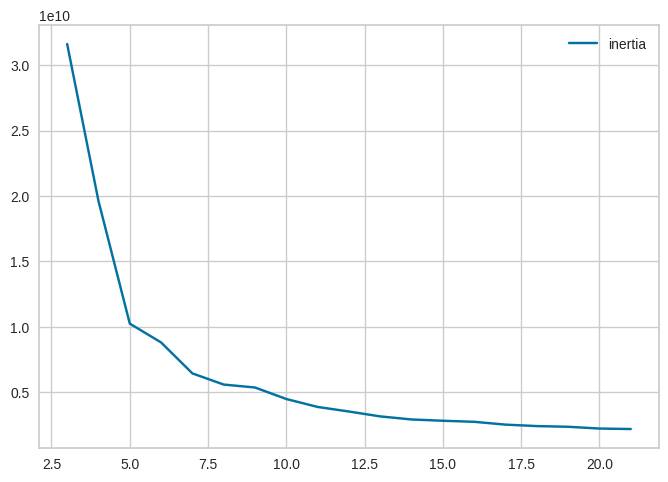

In [135]:
inertia_df.plot()

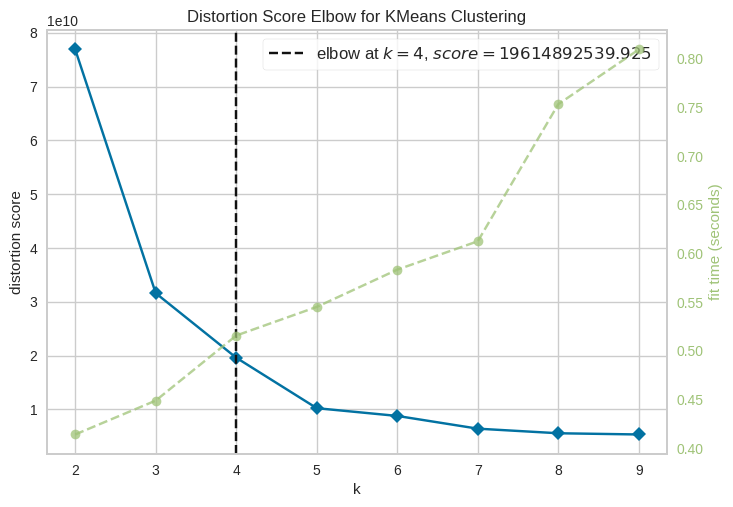

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [136]:
visualizer = KElbowVisualizer(clusterer, k=(2,10), force_model=True)
visualizer.fit(X)
visualizer.show()

In [137]:
X_sample = X.sample(frac=0.17, random_state=42)
print(X_sample.shape)

(90882, 53)


## Подготовка ответов

In [138]:
%%time
from sklearn.cluster import KMeans

n_clusters = 4

clusterer = KMeans(n_clusters=n_clusters, random_state=42)

cluster_labels = clusterer.fit_predict(X)

# inertia
inertia = clusterer.inertia_

CPU times: user 1.69 s, sys: 126 ms, total: 1.81 s
Wall time: 515 ms


In [139]:
predictions = pd.DataFrame(cluster_labels, columns=['activityID'])
predictions = predictions.reset_index()

predictions

,index,activityID
0,0,3
1,1,1
2,2,0
3,3,1
4,4,3
...,...,...
534596,534596,1
534597,534597,2
534598,534598,2
534599,534599,1


In [140]:
predictions_copy = predictions.copy()
predictions_copy['activityID'].unique()

array([3, 1, 0, 2], dtype=int32)

In [141]:
predictions = predictions_copy.copy()

### checkpoint

In [142]:
predictions['activityID'].unique()

array([3, 1, 0, 2], dtype=int32)

In [143]:
%%time
predictions['new_label'] = -1

for index, row in predictions.iterrows():
    if row['activityID'] == 3:
        predictions.loc[index, 'new_label'] = 1
    if row['activityID'] == 1:
        predictions.loc[index, 'new_label'] = 2
    if row['activityID'] == 0:
        predictions.loc[index, 'new_label'] = 3
    if row['activityID'] == 2:
        predictions.loc[index, 'new_label'] = 4

predictions

CPU times: user 52 s, sys: 86 ms, total: 52.1 s
Wall time: 51.5 s


,index,activityID,new_label
0,0,3,1
1,1,1,2
2,2,0,3
3,3,1,2
4,4,3,1
...,...,...,...
534596,534596,1,2
534597,534597,2,4
534598,534598,2,4
534599,534599,1,2


In [144]:
predictions_new_label_copy = predictions.copy()

In [145]:
predictions = predictions_new_label_copy.copy()

In [146]:
predictions

,index,activityID,new_label
0,0,3,1
1,1,1,2
2,2,0,3
3,3,1,2
4,4,3,1
...,...,...,...
534596,534596,1,2
534597,534597,2,4
534598,534598,2,4
534599,534599,1,2


In [147]:
predictions = predictions.drop(columns=['activityID', ])
predictions

,index,new_label
0,0,1
1,1,2
2,2,3
3,3,2
4,4,1
...,...,...
534596,534596,2
534597,534597,4
534598,534598,4
534599,534599,2


In [148]:
predictions.columns = ['Index', 'activityID']

In [149]:
predictions

,Index,activityID
0,0,1
1,1,2
2,2,3
3,3,2
4,4,1
...,...,...
534596,534596,2
534597,534597,4
534598,534598,4
534599,534599,2


In [150]:
prev_submit = pd.read_csv('./clustering-physical-activity-data/submition_baseline_KMeans_4.csv')

In [151]:
all(prev_submit == predictions)

True

In [152]:
predictions.to_csv('./clustering-physical-activity-data/submition_baseline_KMeans_4.csv', index=False)

In [153]:
predictions

,Index,activityID
0,0,1
1,1,2
2,2,3
3,3,2
4,4,1
...,...,...
534596,534596,2
534597,534597,4
534598,534598,4
534599,534599,2


**Пример того как преобразовать номера кластеров.**

In [154]:
import pandas as pd

d = {"f1":pd.Series([100, 20, 3, 5, 200, 400, 2, 282]),
     "f2": pd.Series(['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8']),
     "label": pd.Series([2, 0, 1, 1, 2, 0, 1, 2])}


df0 = pd.DataFrame(d)
df0

,f1,f2,label
0,100,v1,2
1,20,v2,0
2,3,v3,1
3,5,v4,1
4,200,v5,2
5,400,v6,0
6,2,v7,1
7,282,v8,2


In [155]:
df0['label'].unique()

array([2, 0, 1])

In [156]:
df0['new_label'] = -1

for index, row in df0.iterrows():
    if row['label'] == 2:
        df0.loc[index, 'new_label'] = 1
    if row['label'] == 0:
        df0.loc[index, 'new_label'] = 2
    if row['label'] == 1:
        df0.loc[index, 'new_label'] = 3

df0

,f1,f2,label,new_label
0,100,v1,2,1
1,20,v2,0,2
2,3,v3,1,3
3,5,v4,1,3
4,200,v5,2,1
5,400,v6,0,2
6,2,v7,1,3
7,282,v8,2,1
